In [42]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
f_sig = "../coffea/AllInOne_2022/AllInOne.coffea"

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
average= [1175.66666667 1368.33333333 1619.66666667 1482.66666667 1231.33333333
 2470.66666667  965.66666667  616.          407.66666667  267.66666667
  152.          115.66666667  142.33333333]


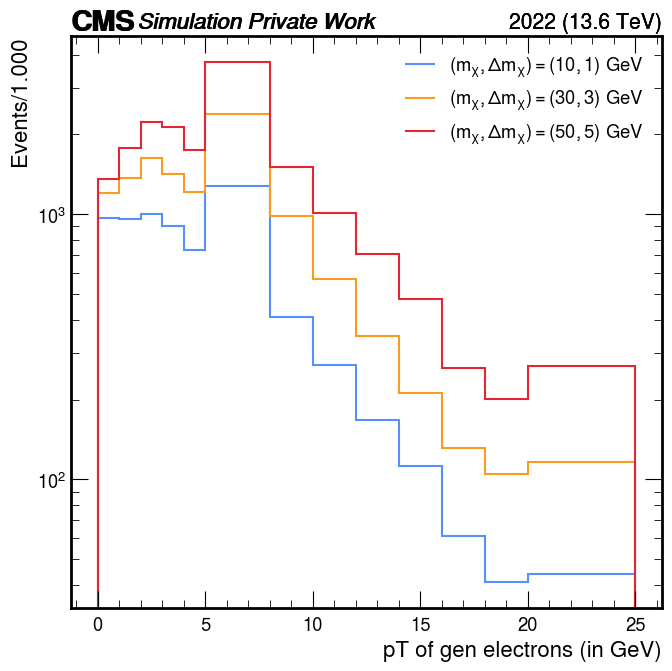

In [44]:
fig, ax = plt.subplots(figsize=(7,7))

delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable':'gen_ele_pt',
    'cut': 'cut3',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': False, 
    'xlabel': "pT of gen electrons (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}



#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts, edges = zip(*results)

counts = np.array(counts)     # shape: (n_m1, n_bins)
edges  = np.array(edges)      # shape: (n_m1, n_edges)

# counts, edges = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


mask = counts != 0

bins_x = (edges[:,:-1] + edges[:,1:])*(0.5)

counts_nonzero_den = np.where(mask, counts, np.nan)
edges_nonzero_den  = np.where(mask, bins_x, np.nan)


avg_den = np.mean(counts_nonzero_den, axis=0)
print("average=", avg_den)


# total = np.sum(counts_nonzero_den)
# print ("TOTAL number of gen electrons:", total)


Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [   1.33333333  192.          685.          720.          604.
 1023.33333333  381.33333333  295.          207.          136.
   73.33333333   59.33333333   73.        ]
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [1.33333333e+00 1.92000000e+02 8.35333333e+02 9.75666667e+02
 8.74333333e+02 1.83766667e+03 7.54333333e+02 4.90000000e+02
 3.27000000e+02 2.20666667e+02 1.21333333e+02 9.93333333e+01
 1.21666667e+02]


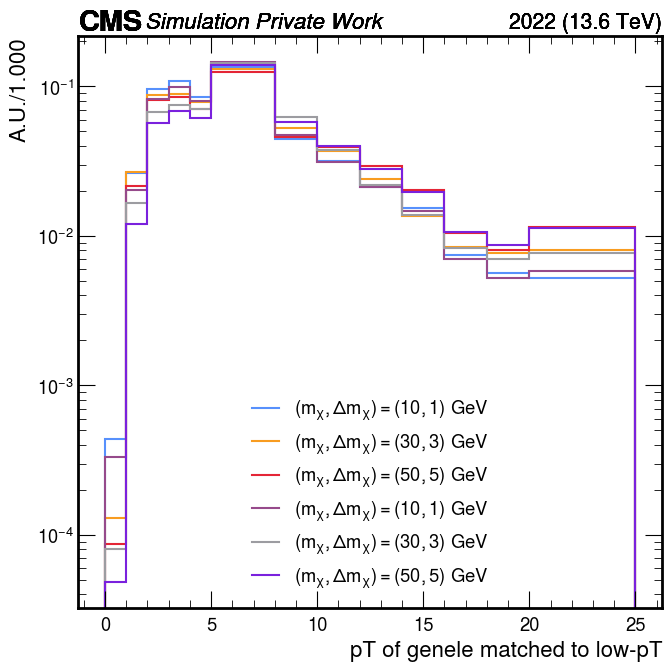

In [45]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'pT_genElePos_Lpt', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_xcleaned = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_xcleaned, edges_xcleaned = zip(*results_xcleaned)

counts_xcleaned = np.array(counts_xcleaned)     # shape: (n_m1, n_bins)
edges_xcleaned  = np.array(edges_xcleaned)      # shape: (n_m1, n_edges)


bins_x_xcleaned = (edges_xcleaned[:,:-1] + edges_xcleaned[:,1:])*(0.5)



avg_num_Xcleanedcase = np.mean(counts_xcleaned, axis=0)
print("average=", avg_num_Xcleanedcase)

################################################################################################################################



plot_dict = {'variable': 'pT_genElePos_Lpt_Noxclean', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}


#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_noxcleaned = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_noxcleaned, edges_noxcleaned = zip(*results_noxcleaned)

counts_noxcleaned = np.array(counts_noxcleaned)     # shape: (n_m1, n_bins)
edges_noxcleaned  = np.array(edges_noxcleaned)      # shape: (n_m1, n_edges)


bins_x_noxcleaned = (edges_noxcleaned[:,:-1] + edges_noxcleaned[:,1:])*(0.5)



avg_num_noXcleanedcase = np.mean(counts_noxcleaned, axis=0)
print("average=", avg_num_noXcleanedcase)

Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [  0.           0.         166.33333333 272.         284.33333333
 883.33333333 406.66666667 212.66666667 128.33333333  93.33333333
  51.66666667  42.33333333  50.        ]


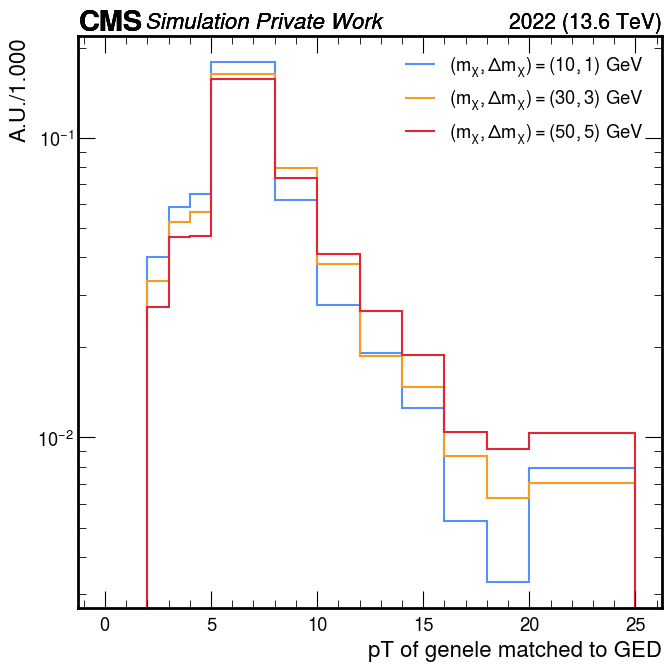

In [46]:
fig, ax = plt.subplots(figsize=(7,7))



plot_dict = {'variable': 'pT_genElePos_GED', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to GED",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_GED = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_GED, edges_GED = zip(*results_GED)

counts_GED = np.array(counts_GED)     # shape: (n_m1, n_bins)
edges_GED  = np.array(edges_GED)      # shape: (n_m1, n_edges)


bins_x_GED = (edges_GED[:,:-1] + edges_GED[:,1:])*(0.5)



avg_num_GED = np.mean(counts_GED, axis=0)
print("average=", avg_num_GED)


In [47]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_noxclean, unc_eff_noxclean = eff_determine_unc(avg_num_noXcleanedcase, avg_den)
print ("efficiency_noxclean:",efficiency_noxclean)

efficiency_xcleaned, unc_eff_xcleaned = eff_determine_unc(avg_num_Xcleanedcase, avg_den)
print ("efficiency_xcleaned:",efficiency_xcleaned)

efficiency_GED, unc_eff_GED = eff_determine_unc(avg_num_GED, avg_den)
print ("efficiency_GED:",efficiency_GED)

efficiency_noxclean: [0.00113411 0.14031669 0.51574398 0.65804856 0.71007038 0.74379385
 0.78115292 0.79545455 0.80212592 0.82440847 0.79824561 0.85878963
 0.85480094]
efficiency_xcleaned: [0.00113411 0.14031669 0.42292653 0.48561151 0.49052518 0.4141932
 0.39489127 0.4788961  0.50776778 0.50809465 0.48245614 0.5129683
 0.51288056]
efficiency_GED: [0.         0.         0.10269603 0.18345324 0.230915   0.35752833
 0.4211253  0.3452381  0.31479967 0.3486924  0.33991228 0.36599424
 0.35128806]


In [48]:
print ("bins_x_noxcleaned=", bins_x_noxcleaned)
print ("bins_x_xcleaned=", bins_x_xcleaned)
print ("bins_x_GED=", bins_x_GED)

bins_x_noxcleaned= [[ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  22.5]
 [ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  22.5]
 [ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  22.5]]
bins_x_xcleaned= [[ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  22.5]
 [ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  22.5]
 [ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  22.5]]
bins_x_GED= [[ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  22.5]
 [ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  22.5]
 [ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  22.5]]


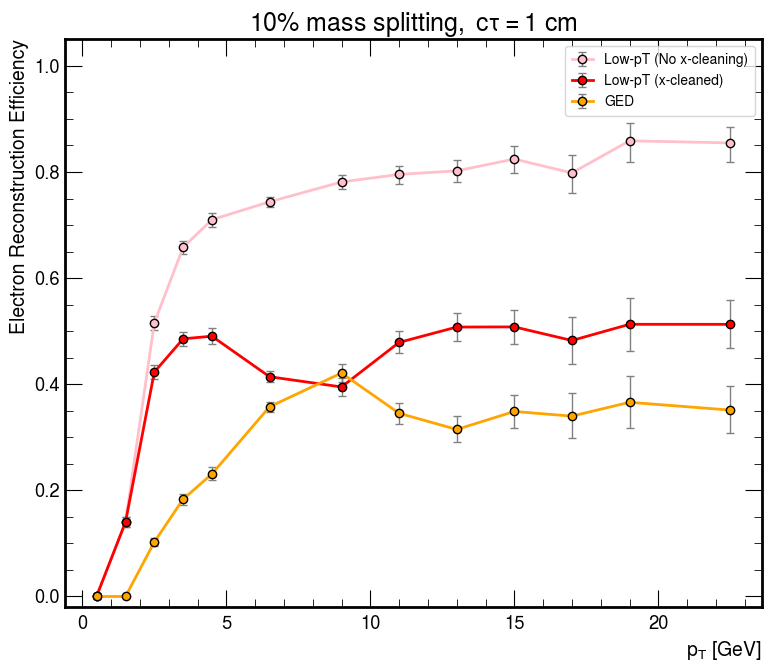

In [52]:
plt.figure(figsize=(8,7))

plt.errorbar(
    bins_x_noxcleaned[0,:],
    efficiency_noxclean,
    yerr=unc_eff_noxclean,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='pink',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (No x-cleaning)'
)

plt.errorbar(
    bins_x_xcleaned[0,:],
    efficiency_xcleaned,
    yerr=unc_eff_xcleaned,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='red',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (x-cleaned)'
)

plt.errorbar(
    bins_x_GED[0,:],
    efficiency_GED,
    yerr=unc_eff_GED,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='orange',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='GED'
)

# Axis styling
plt.ylim(-0.02, 1.05)
plt.xlabel(r"$p_T$ [GeV]", fontsize=14)
plt.ylabel("Electron Reconstruction Efficiency", fontsize=14)



# Grid helps readability
# plt.grid(True, linestyle='--', alpha=0.4)

# Better title formatting


plt.title(
    
    r"$10\%\ \mathrm{mass\ splitting},\ c\tau = 1\ \mathrm{cm}$",
    fontsize=18
)



plt.legend(fontsize=10, frameon=True, loc='upper right')

plt.tight_layout()

plt.savefig("L_lxy_ERE.png", dpi=300)